In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4) (1).zip


In [4]:
import zipfile

zip_file = "archive (4).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [5]:
import os

os.listdir()

['.config',
 'archive (4) (1).zip',
 'archive (4).zip',
 'IMDb Movies India.csv',
 'sample_data']

In [6]:
import pandas as pd

df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

In [7]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
# Display the first 5 rows
print("First 5 Rows:")
display(df.head())

# Display the last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

# Check the shape of the dataset
print("\nShape of Dataset:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Get dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Display statistical summary for categorical columns
print("\nCategorical Summary:")
display(df.describe(include='object'))

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali



Last 5 Rows:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN
15508,Zulm-O-Sitam,(1998),130 min,"Action, Drama",6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja



Shape of Dataset:
(15509, 10)

Column Names:
Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Statistical Summary:


,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000



Categorical Summary:


,Name,Year,Duration,Genre,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7920,14984,13892,13125,12365
unique,13838,102,182,485,2034,5938,4718,4891,4820
top,Mamta,(2019),120 min,Drama,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,227,58,158,83,91



Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [9]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Display missing values before cleaning
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

# Fill missing values in categorical columns with the mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill missing values in numerical columns with the median
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Check if any missing values remain
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Display the updated dataset
print("\nUpdated Dataset:")
display(df.head())

# Display the new dataset shape
print("\nDataset Shape After Cleaning:")
print(df.shape)

Missing Values Before Cleaning:
Name           0
Year         527
Duration    8264
Genre       1876
Rating      7584
Votes       7583
Director     524
Actor 1     1615
Actor 2     2381
Actor 3     3140
dtype: int64


/tmp/ipykernel_743/3168527998.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_743/3168527998.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u


Missing Values After Cleaning:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

Updated Dataset:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,(2019),120 min,Drama,6.0,8,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",6.0,8,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,6.0,8,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali



Dataset Shape After Cleaning:
(15503, 10)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Remove unnecessary columns if they exist
columns_to_drop = ['Name']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Separate features and target
X = df.drop('Rating', axis=1)
y = df['Rating']

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Numerical Features:
[]

Categorical Features:
['Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Training Set Shape: (12402, 8)
Testing Set Shape: (3101, 8)


In [12]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest Regressor model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Create a pipeline that combines preprocessing and model training
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Train the model
pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = pipeline.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Model Performance")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Compare Actual vs Predicted Ratings
comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

print("\nActual vs Predicted Ratings (First 10 Rows)")
display(comparison.head(10))

Model Performance
------------------------------
Mean Absolute Error (MAE): 0.4919
Mean Squared Error (MSE): 0.7558
Root Mean Squared Error (RMSE): 0.8694
R² Score: 0.2269

Actual vs Predicted Ratings (First 10 Rows)


,Actual Rating,Predicted Rating
0,6.1,6.904
1,3.6,5.697
2,5.8,6.581
3,6.0,6.000
4,6.0,6.000
5,6.0,5.781
6,6.7,6.663
7,6.0,6.000
8,7.2,6.746
9,4.2,6.000


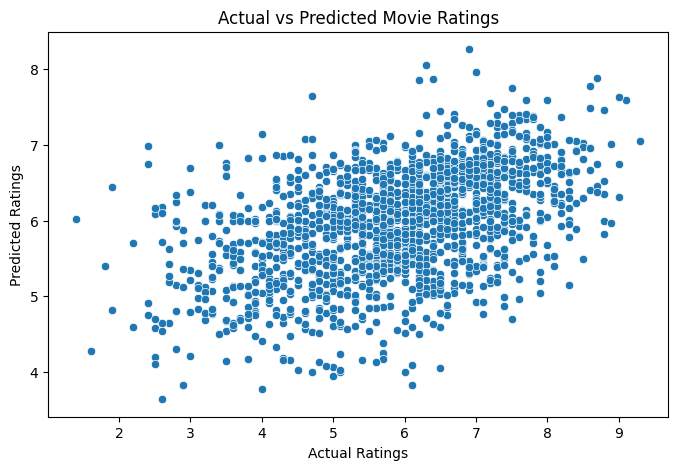

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs Predicted Ratings Plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

In [15]:
# Get feature names after preprocessing

feature_names = (
    pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

# Get feature importance values

importance = pipeline.named_steps['model'].feature_importances_

# Create dataframe

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
2314,cat__Votes_8,0.022755
520,cat__Genre_Documentary,0.012687
553,cat__Genre_Drama,0.012408
280,cat__Genre_Action,0.011517
656,cat__Genre_Horror,0.009858
122,cat__Duration_120 min,0.009790
18350,cat__Actor 3_Pran,0.008091
84,cat__Year_(2005),0.005528
82,cat__Year_(2003),0.005417
99,cat__Year_(2020),0.004979


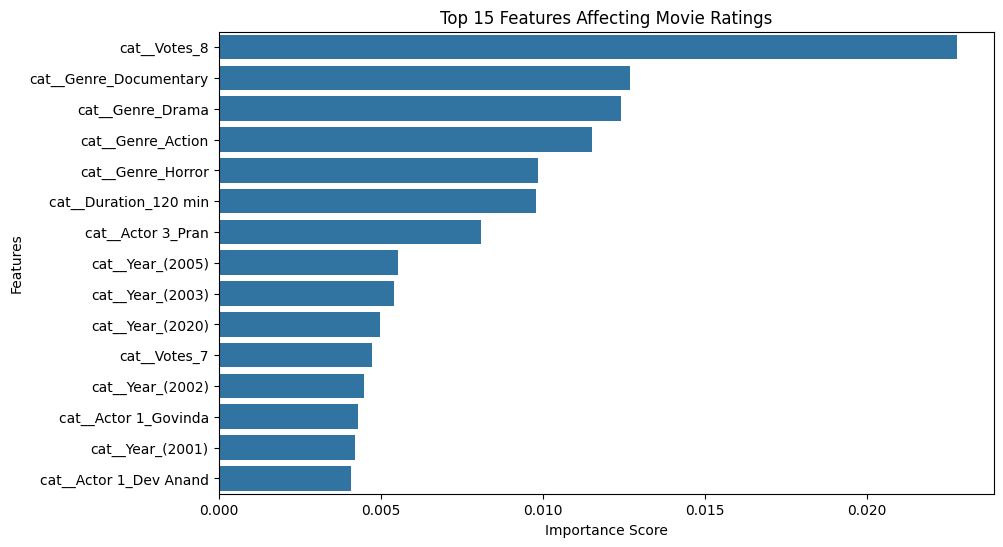

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Features Affecting Movie Ratings")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [17]:
import joblib

joblib.dump(
    pipeline,
    "movie_rating_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [19]:
print(X.columns)

Index(['Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1', 'Actor 2',
       'Actor 3'],
      dtype='object')


In [21]:
print(X.columns.tolist())

['Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [22]:
new_movie = pd.DataFrame({
    'Year': ['2010'],
    'Duration': ['150 min'],
    'Genre': ['Drama'],
    'Votes': ['10000'],
    'Director': ['Rajkumar Hirani'],
    'Actor 1': ['Aamir Khan'],
    'Actor 2': ['Kareena Kapoor'],
    'Actor 3': ['Sharman Joshi']
})

prediction = pipeline.predict(new_movie)

print("Predicted Movie Rating:", prediction[0])

Predicted Movie Rating: 6.905000000000002


In [23]:
df['Duration'] = df['Duration'].str.replace(' min','')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

In [24]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  []),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Year', 'Duration', 'Genre',
                                                   'Votes', 'Director',
                                                   'Actor 1', 'Actor 2',
                                                   'Actor 3'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [25]:
prediction = pipeline.predict(new_movie)

print("Predicted Movie Rating:", prediction[0])

Predicted Movie Rating: 6.905000000000002
